**CHOCOLATE SALES DATASET 2023-2024**  
This dataset contains synthetic retail transaction data from Kaggle for chocolate sales across multiple stores, customers, and products during the years **2023–2024**. It will be used to do sales analytics, customer behavior analysis and retail performance evaluation

**Importing Required Libraries**

In [1]:
import zipfile

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb


**1.0 Data Loading and Initial Inspection**

**Looking for the files in the Zip folder**


In [2]:
with zipfile.ZipFile("../datasets/chocolate-sales-2023-2024.zip", "r") as z:
    for filename in z.namelist():
        print(filename)

calendar.csv
customers.csv
products.csv
sales.csv
stores.csv


**Making Dataframes for each csv file for easy analysis**

In [3]:
dataframes = {}
with zipfile.ZipFile("../datasets/chocolate-sales-2023-2024.zip", "r") as z:
    for csv_name in z.namelist():
        with z.open(csv_name, "r") as f:
            dataframes[csv_name] = pd.read_csv(f)

dataframes.keys()

dict_keys(['calendar.csv', 'customers.csv', 'products.csv', 'sales.csv', 'stores.csv'])

Inspecting the calendar Dataframe

In [17]:
print(dataframes["calendar.csv"].info())
print(dataframes["calendar.csv"].head())
len(dataframes["calendar.csv"])

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   date         731 non-null    str  
 1   year         731 non-null    int64
 2   month        731 non-null    int64
 3   day          731 non-null    int64
 4   week         731 non-null    int64
 5   day_of_week  731 non-null    int64
dtypes: int64(5), str(1)
memory usage: 34.4 KB
None
         date  year  month  day  week  day_of_week
0  2023-01-01  2023      1    1    52            6
1  2023-01-02  2023      1    2     1            0
2  2023-01-03  2023      1    3     1            1
3  2023-01-04  2023      1    4     1            2
4  2023-01-05  2023      1    5     1            3


731

The calendar.csv dataframe has one problem, the date column has a string data type instead of date

Inspecting the customers Dataframe

In [18]:
print(dataframes["customers.csv"].info())
print(dataframes["customers.csv"].head())
len(dataframes["customers.csv"])

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customer_id     50000 non-null  str  
 1   age             50000 non-null  int64
 2   gender          50000 non-null  str  
 3   loyalty_member  50000 non-null  int64
 4   join_date       50000 non-null  str  
dtypes: int64(2), str(3)
memory usage: 1.9 MB
None
  customer_id  age  gender  loyalty_member   join_date
0     C000001   40    Male               1  2025-05-21
1     C000002   47    Male               0  2021-12-26
2     C000003   58  Female               1  2022-09-13
3     C000004   25  Female               0  2025-02-27
4     C000005   43    Male               0  2023-08-31


50000

The join_date and loyalty_member columns have incorrect data types. They need to have date and boolean data types respectively

Inspecting the products Dataframe

In [ ]:
print(dataframes["products.csv"].info())
print(dataframes["products.csv"].head())
len(dataframes["products.csv"])

The products.csv dataframe has no problems

Inspecting the sales Dataframe

In [ ]:
print(dataframes["sales.csv"].info())
print(dataframes["sales.csv"].head())
len(dataframes["sales.csv"])

The oder_date is has wrong data type

Inspecting the stores Dataframe

In [ ]:
print(dataframes["stores.csv"].info())
print(dataframes["stores.csv"].head())
len(dataframes["stores.csv"])

The stores.csv dataframes is good

The data shows that the sales.csv is related to the remaining four dataframes which means the five data frames can be merged into one data frame.

In [ ]:
print(dataframes.keys())

**Data Cleaning**

Converting the data type of date column for the calendar

In [ ]:
dataframes["calendar.csv"]["date"] = pd.to_datetime(dataframes["calendar.csv"]["date"])
dataframes["calendar.csv"].dtypes

In [ ]:
#Converting join_date to datetime data type in customers dataframe
dataframes["customers.csv"]["join_date"] = pd.to_datetime(dataframes["customers.csv"]["join_date"])

#Converting order_date to datetime data type in sales dataframe
dataframes["sales.csv"]["order_date"] = pd.to_datetime(dataframes["sales.csv"]["order_date"])

**EXPLORATORY DATA ANALYSIS**

Exploring the sales dataframe

In [ ]:
#sales_df.head()

In [4]:
#Renaming it for easy reference
sales_df = dataframes["sales.csv"]
sales_df.describe()

,quantity,unit_price,discount,revenue,cost,profit
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,2.999589,9.002449,0.056248,25.486129,15.291554,10.194565
std,1.413621,3.462902,0.076809,16.367864,9.972706,6.778760
min,1.000000,3.000000,0.000000,2.400000,1.200000,0.730000
25%,2.000000,6.000000,0.000000,12.160000,7.240000,4.780000
50%,3.000000,9.010000,0.000000,21.920000,13.030000,8.600000
75%,4.000000,12.000000,0.150000,35.880000,21.410000,14.170000
max,5.000000,15.000000,0.200000,75.000000,52.430000,37.430000


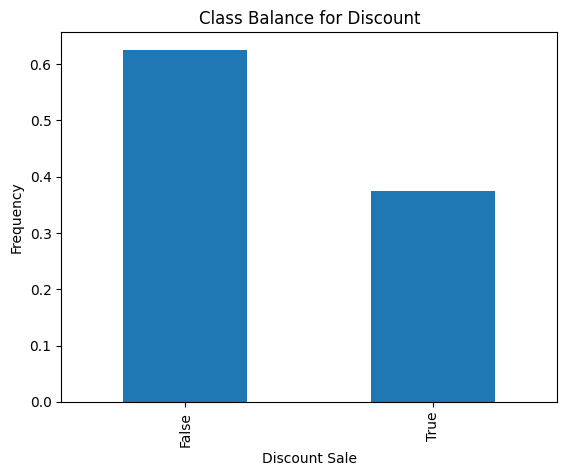

In [5]:
#Converting the discount column into a boolean
discount_sale = sales_df["discount"] > 0

#Plotting a bar chart to see the balance between the quantity of sales made on discount and sales made without discount
discount_sale.value_counts(normalize=True).plot(kind="bar")
plt.title("Class Balance for Discount")
plt.ylabel("Frequency")
plt.xlabel("Discount Sale");

It has been discovered that over 60% sale transactions were made without discount and arount 40% of the total number of sales were made with some discount. Let's now see which of the two scenarios generated more cash

In [6]:
#Total discounts given
float(round(sales_df["discount"].sum(), 2))

56247.85

In [7]:
#Total revenue made from the each class sales
sales_df["discount"] = discount_sale

total_revenue = (sales_df.groupby(sales_df["discount"])["revenue"].sum())/sales_df["revenue"].sum()
total_revenue

discount
False    0.662587
True     0.337413
Name: revenue, dtype: float64

In [9]:
#Total cost made on the each class sales
sales_df["discount"] = discount_sale

total_revenue = (sales_df.groupby(sales_df["discount"])["cost"].sum())/sales_df["cost"].sum()
total_revenue

discount
False    0.662512
True     0.337488
Name: cost, dtype: float64

In [10]:
#Total profits made from the each class sales
sales_df["discount"] = discount_sale

total_sales = (sales_df.groupby(sales_df["discount"])["profit"].sum())/sales_df["profit"].sum()
total_sales

discount
False    0.662699
True     0.337301
Name: profit, dtype: float64

From the analysis of the two discount classes above it shows that the discount sales have no visible impact on the sales revenue, costs and profits. I assumed that from the around 30% sales transactions made on sales with discount, the profit percentage would be more than that as I assumed that most transactions on discount sales would have more sales value beacause of the discount. But it has been shown in the analysis about that discount sales are accounting around the same 30% making my assumption wrong.

Let's now see the impact of store, chocolate type, time of the year and order quantity on the chocolate business

In [66]:
sales_df.head(1)
stores = dataframes["stores.csv"]
stores.head(1)

,store_id,store_name,city,country,store_type
0,S001,Chocolate Store 1,New York,Canada,Retail


In [113]:
stores_df["city"].value_counts()

city
Toronto      18
Paris        16
London       16
New York     15
Sydney       13
Melbourne    12
Berlin       10
Name: count, dtype: int64

In [105]:
summary = sales_stores_df.groupby(["country", "city", "store_type"],as_index=False)["profit"].sum()
summary["country_total_profit"] = summary.groupby("country")["profit"].transform("sum")
summary.sort_values(by=["country_total_profit", "city", "profit"], ascending=False).head(50)

,country,city,store_type,profit,country_total_profit
25,Canada,Toronto,Online,204291.49,2033421.87
24,Canada,Toronto,Mall,203507.53,2033421.87
23,Canada,Toronto,Airport,201260.17,2033421.87
22,Canada,Sydney,Online,202886.57,2033421.87
21,Canada,Paris,Online,102567.49,2033421.87
20,Canada,Paris,Mall,102333.38,2033421.87
19,Canada,Paris,Airport,100695.84,2033421.87
17,Canada,New York,Airport,104000.38,2033421.87
18,Canada,New York,Retail,102710.40,2033421.87
15,Canada,Melbourne,Airport,203503.96,2033421.87


In [75]:
#Merging the sales dataframe with stores dataframe
stores_df = dataframes["stores.csv"]
conn = duckdb.connect()
conn.register("stores", stores)
conn.register("sales", sales)

sales_stores_df = conn.execute(
    """
        SELECT sa.*, st.store_name, st.city, st.country, st.store_type
        FROM sales AS sa
        JOIN stores AS st
        ON sa.store_id = st.store_id
    """
).df()

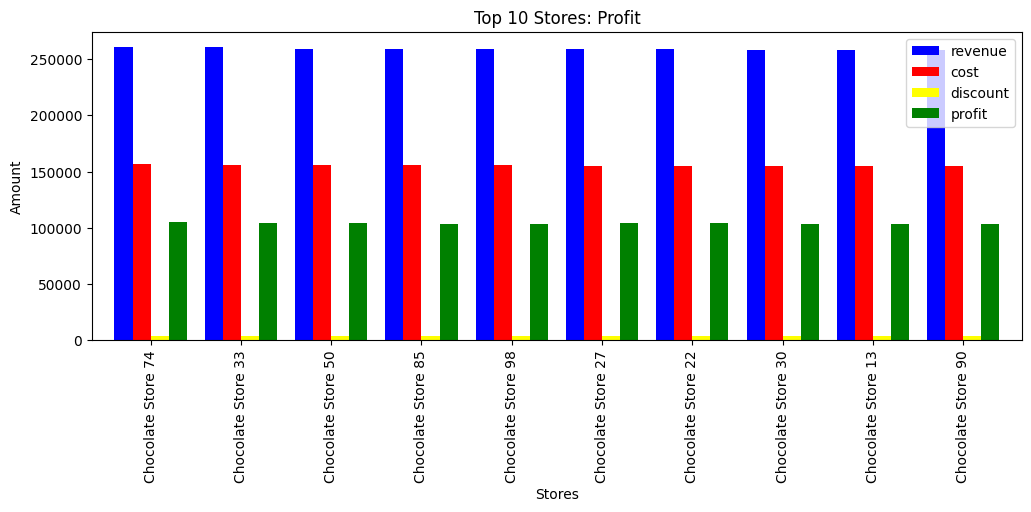

In [81]:
#Total revenue, cost, discount, discount and profit grouped by store name
totals = sales_stores_df.groupby("store_name")[["revenue", "cost", "discount", "profit"]].sum().sort_values(ascending=False, by="revenue")

#top 10 stores by revenue
top10 = totals.head(10)

#Bar graph for the 10 stores
fig, ax = plt.subplots(figsize=(12,4))

#colors for the bars
colors = {
    "revenue": "blue",
    "cost": "red",
    "discount": "yellow",
    "profit": "green"
}

#Graph
top10.plot(kind="bar", ax=ax, width=0.8, color = [colors[col] for col in colors])
ax.set_title("Top 10 Stores: Profit")
ax.set_xlabel("Stores")
ax.set_ylabel("Amount");

In [14]:
con = duckdb.connect()

con.register("calendar", dataframes["calendar.csv"])
con.register("customers", dataframes["customers.csv"])
con.register("products", dataframes["products.csv"])
con.register("sales", dataframes["sales.csv"])
con.register("stores", dataframes["stores.csv"])

df = con.execute(
    """
        SELECT *
        FROM sales as s
        JOIN products as p
        ON s.product_id = p.product_id
        JOIN customers as c
        ON s.customer_id = c.customer_id
    """
).df()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 990236 entries, 0 to 990235
Data columns (total 22 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   order_id        990236 non-null  str    
 1   order_date      990236 non-null  str    
 2   product_id      990236 non-null  str    
 3   store_id        990236 non-null  str    
 4   customer_id     990236 non-null  str    
 5   quantity        990236 non-null  int64  
 6   unit_price      990236 non-null  float64
 7   discount        990236 non-null  float64
 8   revenue         990236 non-null  float64
 9   cost            990236 non-null  float64
 10  profit          990236 non-null  float64
 11  product_id_1    990236 non-null  str    
 12  product_name    990236 non-null  str    
 13  brand           990236 non-null  str    
 14  category        990236 non-null  str    
 15  cocoa_percent   990236 non-null  int64  
 16  weight_g        990236 non-null  int64  
 17  customer_id_1   99023